In [15]:
!pip install imageio
!pip install scikit-image

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
  Using cached networkx-3.2.1-py3-none-any.whl.metadata (5.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 34.4 MB/s eta 0:00:00a 0:00:01
Using cached networkx-3.2.1-py3-none-any.whl (1.6 MB)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [24]:
import imageio.v2 as iio

In [6]:
eight = iio.imread(uri='./eight.tif')
print(type(eight))

<class 'numpy.ndarray'>


In [16]:
# import ipympl
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski

In [18]:
%matplotlib inline

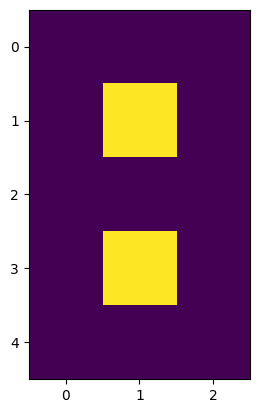

In [19]:
fig, ax = plt.subplots()
ax.imshow(eight)

In [20]:
print(eight.shape)
print(eight)

(5, 3)
[[0. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]


In [26]:
zero = iio.imread('./eight.tif')
zero[2,1]=1.0

[[0. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]


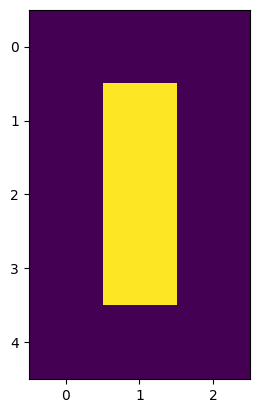

In [ ]:
# the following line od code creates a new figure for imshow 
# to use in displaying our output
fig , ax = plt.subplots()
ax.imshow(zero)
print(zero)

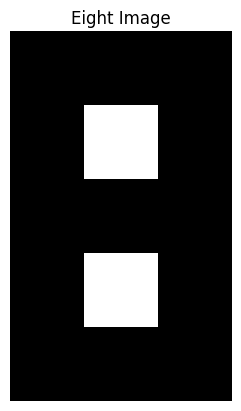

In [30]:
import matplotlib.pyplot as plt
from skimage import io

def show_image(image, title='Image', cmap_type='gray'):
    plt.imshow(image, cmap=cmap_type)
    plt.title(title)
    plt.axis('off')
    plt.show()

zero = io.imread('./eight.tif')
show_image(zero, title='Eight Image')

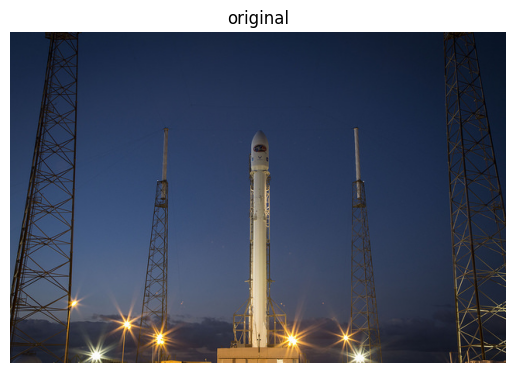

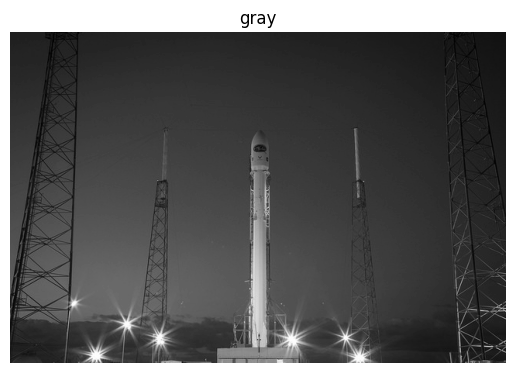

In [29]:
from skimage import data, color
rocket = data.rocket()
gray_scaled_rocket = color.rgb2gray(rocket)
show_image(rocket, 'original')
show_image(gray_scaled_rocket,'gray')


(2457, 3068, 3)

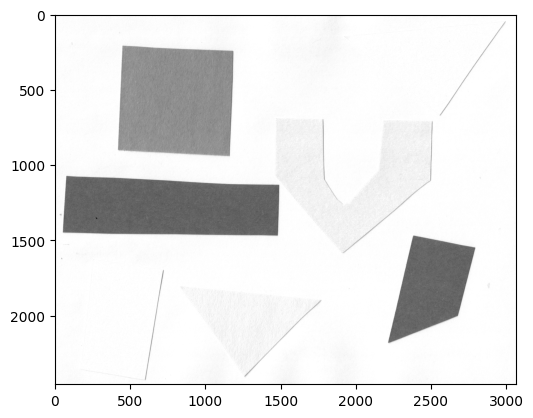

In [33]:
sea=plt.imread('./photos/shapes-01.jpg')
type(sea)

red = sea[:,:,0]		
plt.imshow(red, cmap="gray")

red.shape
sea.shape


[[[116  85  57]
  [128 109  94]
  [214  44  62]
  [219 157  21]]

 [[ 93 152 140]
  [246 198 102]
  [ 70  33 101]
  [  7   1 110]]

 [[225 124 229]
  [154 194 176]
  [227  63  49]
  [144 178  54]]

 [[123 180  93]
  [120   5  49]
  [166 234 142]
  [ 71  85  70]]]


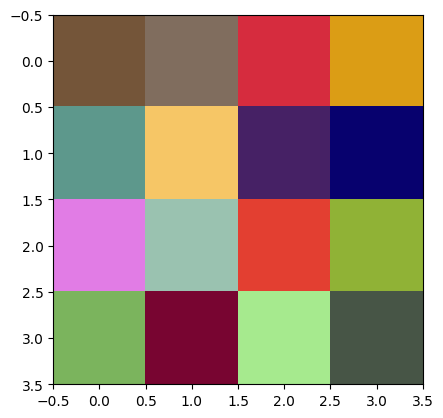

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# set the random seed so we all get the same matrix
pseudorandomizer = np.random.RandomState(2021)

# create a 4 × 4 checkerboard of random colours
checkerboard = pseudorandomizer.randint(0, 255, size=(4, 4, 3))

# restore the default map as you show the image
fig, ax = plt.subplots()
ax.imshow(checkerboard)

# display the arrays
print(checkerboard)


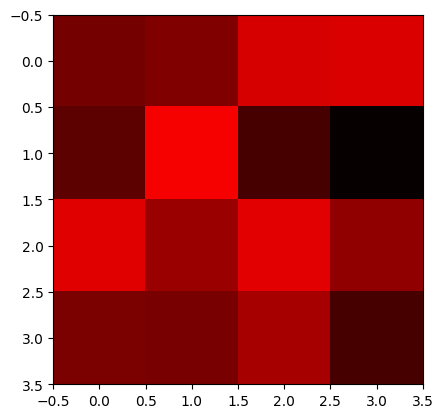

In [35]:
# extract all the colour information for the blue square
upper_right_square = checkerboard[1, 3, :]
upper_right_square

red_channel = checkerboard * [1, 0, 0]
fig, ax = plt.subplots()
ax.imshow(red_channel)


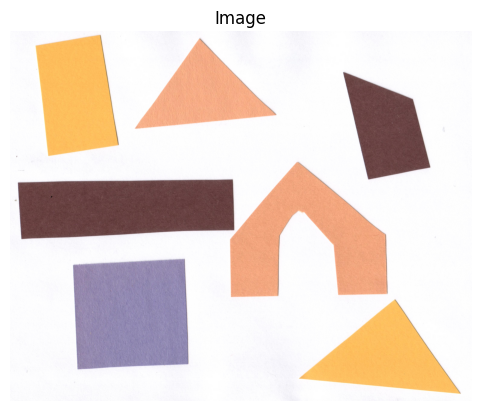

In [36]:
import numpy as np
v = np.flipud(sea)
show_image(v)

#Horizontally?
#	fliplr


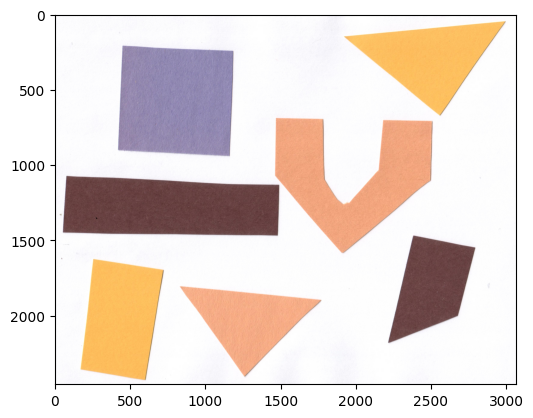

In [40]:

chair = iio.imread(uri="./photos/shapes-01.jpg")
fig, ax = plt.subplots()
ax.imshow(chair)

iio.imwrite(uri="./photos/shapes-01.tif", image=chair)


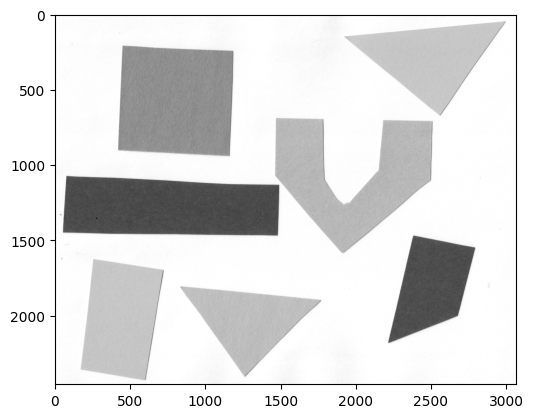

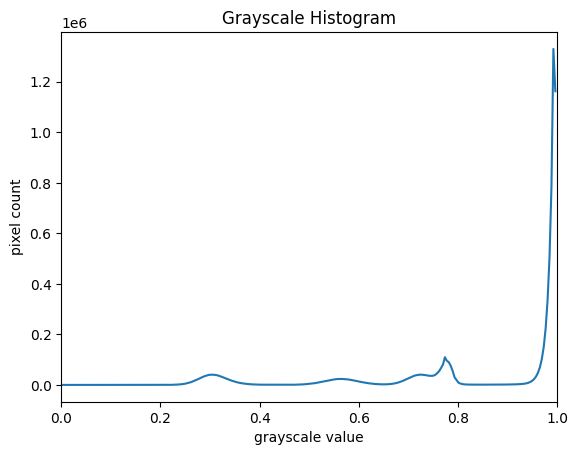

In [41]:
# read the image of a plant seedling as grayscale from the outset
plant_seedling = iio.imread(uri="./photos/shapes-01.jpg", mode="L")

# convert the image to float dtype with a value range from 0 to 1
plant_seedling = ski.util.img_as_float(plant_seedling)

# display the image
fig, ax = plt.subplots()
ax.imshow(plant_seedling, cmap="gray")

# create the histogram
histogram, bin_edges = np.histogram(plant_seedling, bins=256, range=(0, 1))
# configure and draw the histogram figure
fig, ax = plt.subplots()
ax.set_title("Grayscale Histogram")
ax.set_xlabel("grayscale value")
ax.set_ylabel("pixel count")
ax.set_xlim([0.0, 1.0])  # <- named arguments do not work here

ax.plot(bin_edges[0:-1], histogram)  # <- or here


Text(0, 0.5, 'Pixel count')

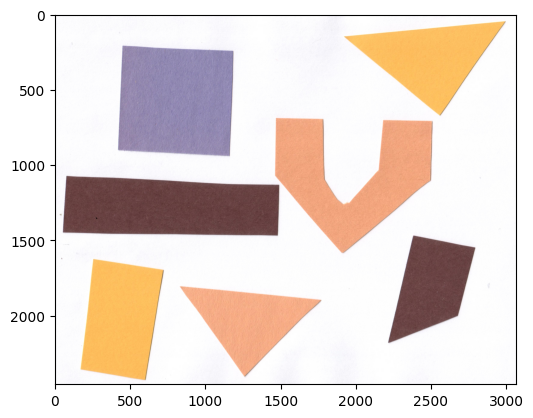

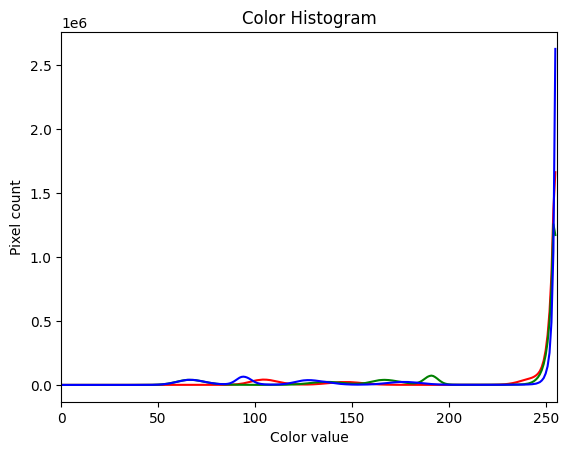

In [42]:
# read original image, in full color
plant_seedling = iio.imread(uri="./photos/shapes-01.jpg")

# display the image
fig, ax = plt.subplots()
ax.imshow(plant_seedling)

# tuple to select colors of each channel line
colors = ("red", "green", "blue")

# create the histogram plot, with three lines, one for
# each color
fig, ax = plt.subplots()
ax.set_xlim([0, 256])
for channel_id, color in enumerate(colors):
    histogram, bin_edges = np.histogram(
        plant_seedling[:, :, channel_id], bins=256, range=(0, 256)
    )
    ax.plot(bin_edges[0:-1], histogram, color=color)

ax.set_title("Color Histogram")
ax.set_xlabel("Color value")
ax.set_ylabel("Pixel count")


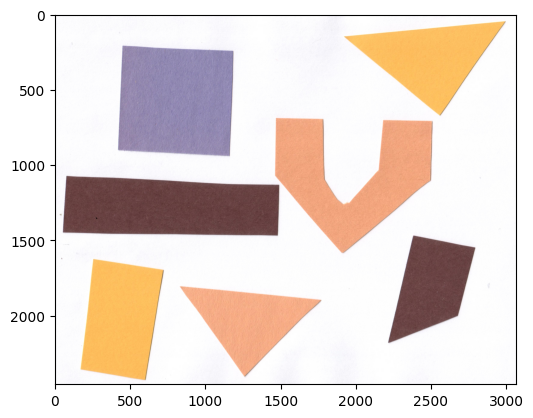

In [44]:
import glob

maize_roots = iio.imread(uri="./photos/shapes-01.jpg")

fig, ax = plt.subplots()
ax.imshow(maize_roots)


(0.0, 1.0)

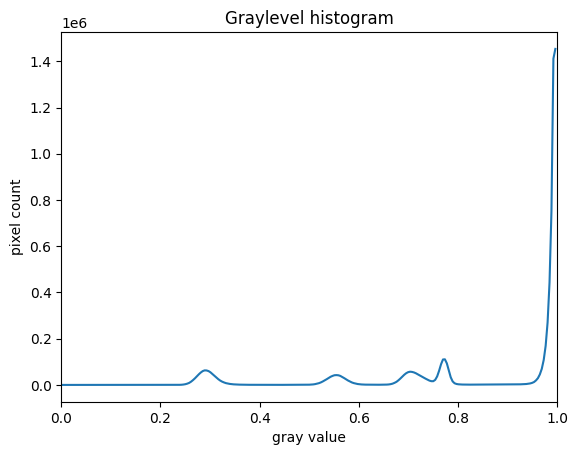

In [45]:
# convert the image to grayscale
gray_image = ski.color.rgb2gray(maize_roots)

# blur the image to denoise
blurred_image = ski.filters.gaussian(gray_image, sigma=1.0)

# show the histogram of the blurred image
histogram, bin_edges = np.histogram(blurred_image, bins=256, range=(0.0, 1.0))
fig, ax = plt.subplots()
ax.plot(bin_edges[0:-1], histogram)
ax.set_title("Graylevel histogram")
ax.set_xlabel("gray value")
ax.set_ylabel("pixel count")
ax.set_xlim(0, 1.0)


Found automatic threshold t = 0.6678970737322817.


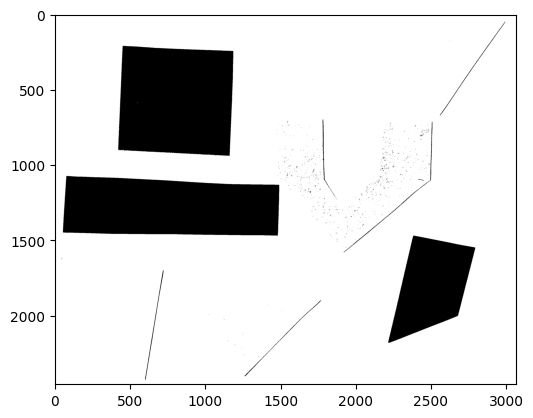

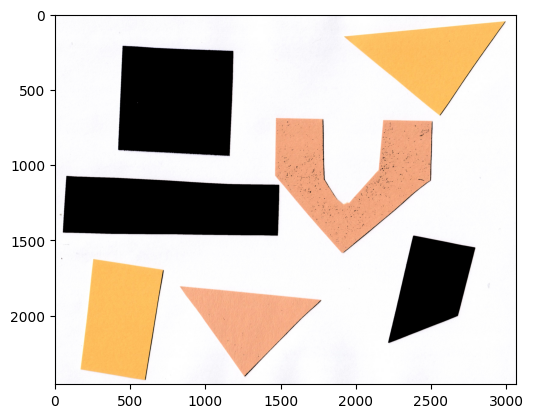

In [46]:
# perform automatic thresholding
t = ski.filters.threshold_otsu(blurred_image)
print("Found automatic threshold t = {}.".format(t))

# create a binary mask with the threshold found by Otsu's method
binary_mask = blurred_image > t

fig, ax = plt.subplots()
ax.imshow(binary_mask, cmap="gray")

# apply the binary mask to select the foreground
selection = maize_roots.copy()
selection[~binary_mask] = 0
fig, ax = plt.subplots()
ax.imshow(selection)
